# Boppart-Krusell-Mitman (BKM) Algorithm and Business Cycle Simulation

## Model with investment-specific technology shocks

Similar to the previous tutorial, we consider an economy in which households make optimal intertemporal decisions regarding consumption and asset holdings. Each household maximizes expected lifetime utility by solving the following dynamic programming problem:

$$
V(k, z; K, Z, Q) = \max_{c, k’} \left\{ u(c) + \beta \sum_{z’} \Pi(z’|z) V(k’, z’; K’, Z’, Q’) \right\}
$$

subject to the constraints:

$$
\begin{aligned}
c_t + Q k_{t+1} &\leq (Q(1-\delta) + r_t)k_t + w_t z_t \\
c_t &\geq 0 \\
k_t &\geq 0
\end{aligned}
$$

Here, $k$ denotes asset holdings, $z$ is an idiosyncratic labor productivity shock, $K$ is the aggregate capital stock, and $Z$ is the aggregate total factor productivity (TFP). Households face idiosyncratic income risk governed by the Markov transition matrix $\Pi(z’|z)$, and take aggregate prices—wages $w_t$ and interest rates $r_t$—as given.

Now, we have an additional variable $Q$. This can be understood as a shock that affects the value of generating new capital (i.e. investment). Hence, a fall in the value of $Q$ increases the capacity for producing capital. The reverse holds for a raise.

### Aggregate Uncertainty: TFP and Investment-specific Technology Shocks

Both aggregate states $S = (Z, Q)$ evolve according to a first-order autoregressive AR(1) process:

$S_t = \rho^S S_{t-1} + \sigma^S \varepsilon_t^S$

where $\rho^S \in (0,1)$ governs the persistence of the shock, $\sigma^S$ is the volatility, and $\varepsilon_t^S \sim \mathcal{N}(0,1)$ represents an i.i.d. innovation.

The rest of the model follows tutorial 7.

In [1]:
using Setfield, PrettyTables, Parameters, Roots, Plots, Statistics

## 1. Define parameters
@with_kw struct NumericalParameters
    nk = 100 # Number of points on the capital grid
    nz = 3 # Number of points on the employment grid
    crit = 1.0e-5 # Precision up to which to solve the value function
    maxk = 50 # highest point on the capital grid
    mink = 0 # lowest point on the capital grid
end
n_par = NumericalParameters()

@with_kw struct EconomicParameters
    r = 0 # Real Rate
    ξ = 2 # Coefficient of relative risk aversion
    β = 0.95 # Discount factor
    α = 0.33 # Curvature of production function
    δ = 0.05 # Depreciation
    b = n_par.mink # borrowing limit
    ρ = 0.9 # Persistence of the AR(1) process
    QSS = 1.0 # Steady state value of investment-specific technology shock
    ρ_Z = 0.95 # persistence of technology shock
    ρ_Q = 0.9 # persistence of investment-specific technology shock
    N = 1 # aggregate labor supply for productivity h
    σ_Z = 0.01 # Std. dev. of TFP shock
    σ_Q = 0.02 # Std. dev. of Inv-spec technology shock
end
m_par = EconomicParameters()

## Produce grids
include("Functions/Tauchen.jl")
grid_z, Π, bounds = Tauchen(m_par.ρ,n_par.nz)
grid_z = exp.(grid_z)

struct Grids
    k # capital
    z # income
end
gri   = Grids(
            exp.(collect(range(log(1),log(n_par.maxk-n_par.mink+1);length = n_par.nk))) .- 1 .+ n_par.mink, # individual capital grid
            grid_z
        )

# Meshes of capital and productivity
meshes = (
            k = [k for k in gri.k, z in gri.z],
            z = [z for k in gri.k, z in gri.z]
         )

# Define marginal utility and inverse marginal utility
if m_par.ξ == 1.0
    util(c)     = log.(c) # Utility
    mutil(c)    = 1.0 ./c  # Marginal utility
    invmutil(mu) = 1.0 ./mu # inverse marginal utility
else
    util(c)      = 1.0/(1.0 - m_par.ξ) .* c .^(1-m_par.ξ) # Utility
    mutil(c)     = 1.0 ./(c .^m_par.ξ) # Marginal utility
    invmutil(mu) = 1.0 ./(mu .^(1.0 ./m_par.ξ)) # inverse marginal utility
end

invmutil (generic function with 1 method)

In [2]:
using CubicSplines, Optim

"""
    VFI_update_spline(V,Y,util,m_par,n_par,gri,Π)

Update the value function (one VFI iteration) for the consumption-savings problem.

    * `V` (dimensions: k x z) is the old value function guess.
    * `Y` (dimensions: k x z) is a matrix of cash at hand
    * `util` is the felicity function.
    * `m_par` and `n_par` are structures containing economic and numerical  parameters.
    * `gri` is the asset and productivity grid.
    * `Π` (dimensions: z x z') is the transition probability matrix.

Returns

    * `Vnew`: (k x z) optimal value function
    * `kprime`: (k x z) asset policy
"""
function VFI_update_spline(V,C,Q,util,m_par,n_par,gri,Π)
    V      = reshape(V,n_par.nk,n_par.nz) # make sure that V has the right format dim1: k, dim2:z
    kprime = zeros(size(V)) # allocate policy matrix
    Vnew   = zeros(size(V)) # allocate new value matrix
    EV     = m_par.β* V* Π'   # Calculate expected continuation value

    for zz = 1:n_par.nz # loop over Incomes
        ev_int = CubicSpline(gri.k,EV[:,zz]) # Prepare interpolant. Similar to griddedInterpolant(,Method='spline') in Matlab, it performs
                                             # interpolation on a N-Dimensional grid
        for kk=1:n_par.nk # loop of Assets
            f(kpri)       = -util(C[kk,zz]- Q * kpri)-ev_int[kpri] # Define function to be minimized
            optimres        = optimize(f,n_par.mink,min(C[kk,zz],n_par.maxk)) 
            Vnew[kk,zz]   = - Optim.minimum(optimres) # Save value
            kprime[kk,zz] = Optim.minimizer(optimres) # Save policy
        end
    end
    return Vnew, kprime
end

VFI_update_spline

In [3]:
include("Functions/Young.jl")

"""
    K_Agg(R,w,par,mpar,Π,meshes,gri)

Calculate the aggregate supply of funds for a 
given interest rate `R` and wage rate `w`.

    * `R`: interest rate
    * `w`: wage rate
    * `par` and `mpar` are parameter structures.
    * `Π` is the transition probability matrix.
    * `meshes` and `gri` are meshes and grids for income (z) and assets (k).

Returns

    * `K`: aggregate supply
    * `kprime`: (k x z) asset policy
    * `marginal_k`: stationary marginal distribution of asset
    * `StDist`: stationary joint distribution (k x z)
    * `Γ`: transition matrix from policy functions (using [`Young()`](@ref)'s method)
    * `C`: (k x z) consumption policy
"""
function K_Agg(R,w,Q,util,n_par,m_par,Π,meshes,gri)
    @set! m_par.r = R

    C = meshes.z*w + meshes.k*(Q*(1-m_par.δ)+m_par.r) # Cash at hand (Labor income plus assets cumulative dividend)
    V    = zeros(n_par.nk,n_par.nz) # Initialize Value Function
    kprime    = zeros(n_par.nk,n_par.nz) # Initialize Policy Function
    distVF = ones(1) # Initialize Distance
    iterVF = 1 # Initialize Iteration count

    while distVF[iterVF]>n_par.crit # Value Function iteration loop: until distance is smaller than crit.
    # Update Value Function using off-grid search
        Vnew,kprime = VFI_update_spline(V,C,Q,util,m_par,n_par,gri,Π) # Optimize given cont' value
        dd          = maximum(abs.(Vnew-V)) # Calculate distance between old guess and update
        V          = Vnew # Update Value Function
        iterVF     += 1 # Count iterations
        append!(distVF,dd)   # Save distance
    end

    Γ, StDist = Young(kprime,gri,n_par,Π)
    marginal_k      = sum(reshape(StDist,n_par.nk, n_par.nz),dims=2)
    K               = dot(marginal_k,gri.k)
    
    return K,kprime,marginal_k, StDist, Γ, V
end

K_Agg

In [4]:
Kdemand(R)      = m_par.N * (m_par.α/R).^(1/(1-m_par.α))         # Calculate capital demand by firms for a given interest rate and employment
rate(K)         = m_par.α* m_par.N.^(1-m_par.α) .* K.^(m_par.α-1)# .-m_par.δ # Calculate the return on capital given K and employment N 
wage(K)         = (1-m_par.α)* m_par.N.^(-m_par.α) .* K.^(m_par.α)          # Calculate the wage rate given K and employment N 
ExcessDemand(K) = K_Agg(rate(K),wage(K),m_par.QSS,util,n_par,m_par,Π,meshes,gri)[1] - K   # Calculate the difference between capital supply and demand for wages and returns given by assumed capital demand

ExcessDemand (generic function with 1 method)

In [5]:
# Rstar = rate(find_zero(ExcessDemand,(Kdemand(0.06),Kdemand(0.01)), Roots.Brent(), atol = 1e-5)) # find equilibrium amount of capital (and corresponding rate)
Rstar = 0.05940131455093975
Kstar           = Kdemand(Rstar)

~,saving_star,marginal_k, StDist, Γ, V =K_Agg(rate(Kstar),wage(Kstar),m_par.QSS,util,n_par,m_par,Π,meshes,gri)
c_star = meshes.z .* wage(Kstar) .+ meshes.k .* (m_par.QSS*(1.0 - m_par.δ)+Rstar) .- saving_star

100×3 Matrix{Float64}:
 0.523779  1.12622  2.10025
 0.564674  1.13481  2.10435
 0.594403  1.14427  2.10854
 0.617926  1.15403  2.11292
 0.64028   1.16353  2.1175
 0.660003  1.17342  2.12208
 0.676101  1.18221  2.12682
 0.69475   1.19153  2.13181
 0.712105  1.20115  2.13694
 0.726934  1.2115   2.14215
 ⋮                  
 3.38435   3.70152  4.22659
 3.45937   3.77516  4.29594
 3.53649   3.85089  4.36747
 3.61578   3.92879  4.44129
 3.69731   4.00892  4.51768
 3.78117   4.09136  4.59718
 3.86742   4.17617  4.68174
 3.95617   4.26386  4.78798
 4.04776   4.35673  5.11099

In [6]:
function backward_update(KT_guess, ZT, QT, VPT::Array{Float64,3}, SPT::Array{Float64,3}, CPT::Array{Float64,3}, util, m_par, n_par, gri, meshes, Π::Array{Float64,2})
    
    T = length(ZT)

    rT         = ZT .* m_par.α .* m_par.N.^(1-m_par.α) .* KT_guess.^(m_par.α-1)
    wT         = ZT .* (1-m_par.α) .* m_par.N.^(-m_par.α) .* KT_guess.^(m_par.α)

    # Start from the steady-state and iterate backwards
    for h = 1:(T-2)
        t = T - h
        
        # Current period interest rate and wage
        r = rT[t]
        w = wT[t]
        Q = QT[t]

        # Update Policy
        CashPT = meshes.z*w + meshes.k*(Q*(1-m_par.δ)+r) # Cash at hand (Labor income plus assets cumulative dividend) with r = rT[t] and w = wT[t]
        VPT[:,:,t], SPT[:,:,t] = VFI_update_spline(VPT[:,:,t+1],CashPT,Q,util,m_par,n_par,gri,Π)
        CPT[:,:,t] = meshes.z .* w .+ meshes.k .* (Q*(1-m_par.δ)+r) .- SPT[:,:,t]
    end

    return VPT, SPT, CPT
end

function forward_update(Kstar::Float64,SPT::Array{Float64,3},DIST::Array{Float64,2},gri,n_par,Π::Array{Float64,2})

    T = size(SPT,3)
    KT_forward = zeros(T)
    KT_forward[1] = Kstar

    for t=2:T
        Γ, StDist = Young(SPT[:,:,t-1],gri,n_par,Π)
        DIST[:,t] = DIST[:,t-1]'*Γ
        KT_forward[t] = dot(sum(reshape(DIST[:,t],n_par.nk,n_par.nz),dims=2),gri.k)
    end

    return DIST, KT_forward
end

function solve_bkm!(Kstar,KT,ZT, QT,VPT,SPT,CPT,DIST,util,m_par,n_par,gri,meshes,Π; convex_combination::Float64 = 0.2,
    shrink_factor::Float64 = 0.5, expand_factor::Float64 = 1.05, maxiter_bkm::Int64 = 1000, tol::Float64=1e-6, verbose::Bool=true, display_iter::Int64 = 20)


    T = length(ZT)

    # Initializations
    diff = 10e10
    diff_old = 10e10
    convergence_flag = 0
    damp = convex_combination
    # stop_crit = 1.0e-5
    # iter = 0

    # while diffKT > stop_crit
    for iter_bkm = 1:maxiter_bkm
        # Step 1: Backward solving for the policy functions
        VPT, SPT, CPT = backward_update(KT[iter_bkm],ZT, QT,VPT,SPT,CPT,util,m_par,n_par,gri,meshes,Π)

        # Step 2: Forward solving for the distribution and K path
        DIST, KTUpdate = forward_update(Kstar,SPT,DIST,gri,n_par,Π)

        # Step 3: Check convergence
        diff = maximum(abs.(KTUpdate-KT[iter_bkm]))

        # Display every display_iter iterations
        if verbose==true
            if mod(iter_bkm,display_iter) == 0
                println("Iteration $(iter_bkm). diff = $(diff)")
            end
        end

        if diff < tol
            if verbose==true
                println("Convergence reached after $(iter_bkm) iterations.")
            end
            convergence_flag = 1
            break
        else
            # Update the guess for the path {K_t}
            # Decrease the dampening factor
            if diff > diff_old
                damp = max(min(damp * shrink_factor, 1.0-eps()), eps())
            # Increase the dampening factor
            else
                damp = max(min(damp * expand_factor, 1.0-eps()), eps())
            end
            if mod(iter_bkm, 10) == 0
                if verbose==true
                    println("damp = $(damp); diff = $(diff)")
                end
            end
            # Store the updated path for {K_t}
            push!(KT, damp.*KTUpdate .+ (1.0 - damp).*KT[iter_bkm])
            diff_old = diff
        end


    end

    return KT, convergence_flag, diff

end

solve_bkm! (generic function with 1 method)

In [7]:
T = 150 #Let us assume that the economy is back to the steady state after max_t periods\

# 3. Generate sequence of TFP and Investment Specific Technology Shocks
ZT = log.(ones(T,1))
ε_Z = zeros(T,1)

QT = log.(ones(T,1))
ε_Q = zeros(T,1)
ε_Q[2] = m_par.σ_Q # Only an investment shock in period 2

for i = 2:T
    ZT[i] = m_par.ρ_Z * ZT[i-1] + m_par.σ_Z * ε_Z[i]
    QT[i] = m_par.ρ_Q * QT[i-1] + m_par.σ_Q * ε_Q[i]
end
ZT = exp.(ZT)
QT = exp.(QT)

150×1 Matrix{Float64}:
 1.0
 1.0004000800106678
 1.0003600648077766
 1.0003240524936692
 1.0002916425194128
 1.0002624744403896
 1.0002362238964715
 1.000212598995964
 1.0001913370626012
 1.0001722017090124
 ⋮
 1.0000000001570404
 1.0000000001413363
 1.0000000001272027
 1.0000000001144824
 1.0000000001030342
 1.0000000000927307
 1.0000000000834577
 1.000000000075112
 1.0000000000676008

In [8]:
# Heroic guess for the initial path of {K_t}: K_t = K* for all t
KT = []
push!(KT, repeat([Kstar], T))

VPT = repeat(V,outer=(1,1,T))            # Guess for the value function in each period
SPT = repeat(saving_star,outer=(1,1,T))  # Guess for the savings policy functions in each period
CPT = repeat(c_star,outer=(1,1,T))       # Guess for the consumption policy function in each period
DIST = repeat(StDist,outer=(1,T))        # Guess for the distribution in each period

300×150 Matrix{Float64}:
 0.0241903    0.0241903    0.0241903    …  0.0241903    0.0241903
 0.00348923   0.00348923   0.00348923      0.00348923   0.00348923
 0.00284398   0.00284398   0.00284398      0.00284398   0.00284398
 0.00270078   0.00270078   0.00270078      0.00270078   0.00270078
 0.00199527   0.00199527   0.00199527      0.00199527   0.00199527
 0.00246104   0.00246104   0.00246104   …  0.00246104   0.00246104
 0.00266965   0.00266965   0.00266965      0.00266965   0.00266965
 0.00225744   0.00225744   0.00225744      0.00225744   0.00225744
 0.00186253   0.00186253   0.00186253      0.00186253   0.00186253
 0.00306966   0.00306966   0.00306966      0.00306966   0.00306966
 ⋮                                      ⋱               
 0.00426088   0.00426088   0.00426088      0.00426088   0.00426088
 0.00342298   0.00342298   0.00342298      0.00342298   0.00342298
 0.00264584   0.00264584   0.00264584      0.00264584   0.00264584
 0.00195438   0.00195438   0.00195438      0.001

In [9]:
# Find the path for {K_t}:
K_path, convergence_flag, diff = solve_bkm!(Kstar,KT,ZT,QT,VPT,SPT,CPT,DIST,util,m_par,n_par,gri,meshes,Π);

damp = 0.3257789253554885; diff = 0.00011379253210463958
Convergence reached after 18 iterations.


In [10]:
# Find the path for other aggregates:
r_path = zeros(length(ZT)) #to store the interest rate on path
w_path = zeros(length(ZT)) #to store the wage on path
for t=length(ZT):-1:1 #iterate backward
    # Next period
    r_path[t] =  ZT[t] .* m_par.α .* m_par.N.^(1-m_par.α) .* K_path[end][t].^(m_par.α-1)
    w_path[t] = ZT[t] .* (1-m_par.α) .* m_par.N.^(-m_par.α) .* K_path[end][t].^(m_par.α) 
end

┌ Info: Saved animation to /Users/albert/Dropbox/0_Teaching/Tuebingen/SoSe 2025/Adv. Macro II/Tutorials/Tutorial 8/K_convergence_Q.gif
└ @ Plots /Users/albert/.julia/packages/Plots/Ec1L1/src/animation.jl:156


Plots.AnimatedGif("/Users/albert/Dropbox/0_Teaching/Tuebingen/SoSe 2025/Adv. Macro II/Tutorials/Tutorial 8/K_convergence_Q.gif")
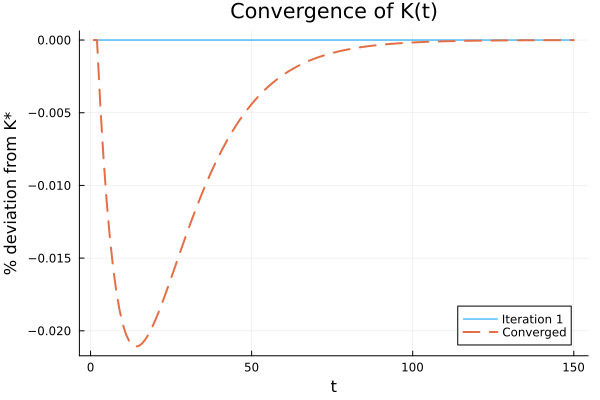

In [11]:
true_K  = K_path[end]        # the converged capital path
anim    = @animate for (n, Kn) in enumerate(K_path)
    # plot the current iterate Kn
    p = plot(1:T,
             log.(Kn ./ Kstar) .* 100,
             label   = "Iteration $n",
             xlabel  = "t",
             ylabel  = "% deviation from K*",
             title   = "Convergence of K(t)",
             legend  = :best)

    # overlay the converged true_K each time
    plot!(p,
          1:T,
          log.(true_K ./ Kstar) .* 100,
          linestyle = :dash,
          lw        = 2,
          label     = "Converged")

    p
end

gif(anim, "K_convergence_Q.gif", fps = 4)

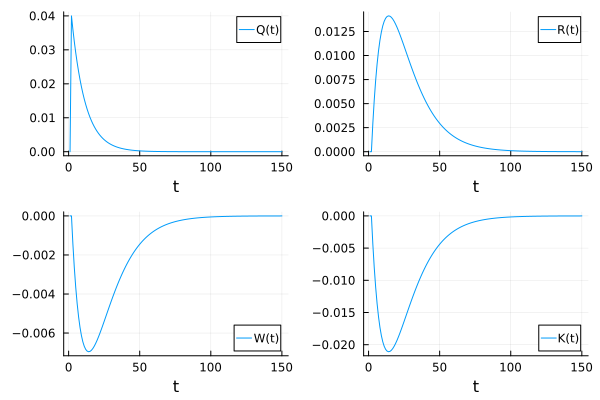

In [12]:
p1 = plot(1:T, log.(QT./QT[end]).*100, label = "Q(t)", xlabel= "t")
p2 = plot(1:T, log.(r_path./r_path[end]).*100, label= "R(t)", xlabel= "t")
p3 = plot(1:T, log.(w_path./w_path[end]).*100, label= "W(t)", xlabel= "t")
p4 = plot(1:T, log.(K_path[end]./Kstar).*100, label= "K(t)", xlabel= "t" )

p5 = plot(p1, p2, p3, p4)

In [13]:
T = 150 #Let us assume that the economy is back to the steady state after max_t periods\

# 3. Generate sequence of TFP and Investment Specific Technology Shocks
ZT_TFP = log.(ones(T,1))
ε_Z = zeros(T,1)
ε_Z[2] = m_par.σ_Z # Only a TFP shock in period 2

QT_TFP = log.(ones(T,1))
ε_Q = zeros(T,1)

for i = 2:T
    ZT_TFP[i] = m_par.ρ_Z * ZT_TFP[i-1] + m_par.σ_Z * ε_Z[i]
    QT_TFP[i] = m_par.ρ_Q * QT_TFP[i-1] + m_par.σ_Q * ε_Q[i]
end
ZT_TFP = exp.(ZT_TFP)
QT_TFP = exp.(QT_TFP)

# Heroic guess for the initial path of {K_t}: K_t = K* for all t
KT_TFP = []
push!(KT_TFP, repeat([Kstar], T))

VPT_TFP = repeat(V,outer=(1,1,T))            # Guess for the value function in each period
SPT_TFP = repeat(saving_star,outer=(1,1,T))  # Guess for the savings policy functions in each period
CPT_TFP = repeat(c_star,outer=(1,1,T))       # Guess for the consumption policy function in each period
DIST_TFP = repeat(StDist,outer=(1,T))        # Guess for the distribution in each period

# Find the path for {K_t}:
K_path_TFP, ~, ~ = solve_bkm!(Kstar,KT_TFP,ZT_TFP,QT_TFP,VPT_TFP,SPT_TFP,CPT_TFP,DIST_TFP,util,m_par,n_par,gri,meshes,Π);

# Find the path for other aggregates:
r_path_TFP = zeros(length(ZT_TFP)) #to store the interest rate on path
w_path_TFP = zeros(length(ZT_TFP)) #to store the wage on path
for t=length(ZT_TFP):-1:1 #iterate backward
    # Next period
    r_path_TFP[t] =  ZT_TFP[t] .* m_par.α .* m_par.N.^(1-m_par.α) .* K_path_TFP[end][t].^(m_par.α-1)
    w_path_TFP[t] = ZT_TFP[t] .* (1-m_par.α) .* m_par.N.^(-m_par.α) .* K_path_TFP[end][t].^(m_par.α) 
end

damp = 0.3257789253554885; diff = 3.960319505935672e-5
Convergence reached after 17 iterations.


┌ Info: Saved animation to /Users/albert/Dropbox/0_Teaching/Tuebingen/SoSe 2025/Adv. Macro II/Tutorials/Tutorial 8/K_convergence_Z.gif
└ @ Plots /Users/albert/.julia/packages/Plots/Ec1L1/src/animation.jl:156


Plots.AnimatedGif("/Users/albert/Dropbox/0_Teaching/Tuebingen/SoSe 2025/Adv. Macro II/Tutorials/Tutorial 8/K_convergence_Z.gif")
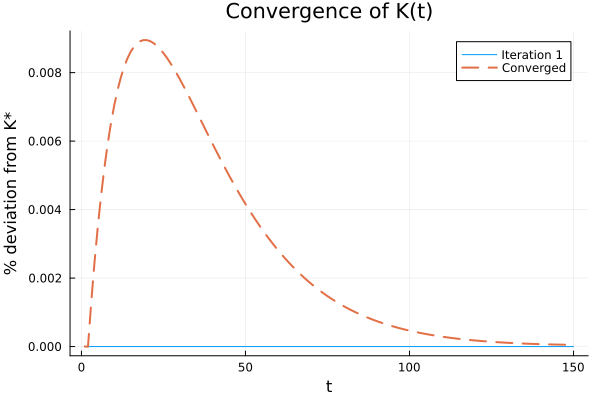

In [14]:
true_K_TFP  = K_path_TFP[end]        # the converged capital path
anim    = @animate for (n, Kn) in enumerate(K_path_TFP)
    # plot the current iterate Kn
    p = plot(1:T,
             log.(Kn ./ Kstar) .* 100,
             label   = "Iteration $n",
             xlabel  = "t",
             ylabel  = "% deviation from K*",
             title   = "Convergence of K(t)",
             legend  = :best)

    # overlay the converged true_K each time
    plot!(p,
          1:T,
          log.(true_K_TFP ./ Kstar) .* 100,
          linestyle = :dash,
          lw        = 2,
          label     = "Converged")

    p
end

gif(anim, "K_convergence_Z.gif", fps = 4)

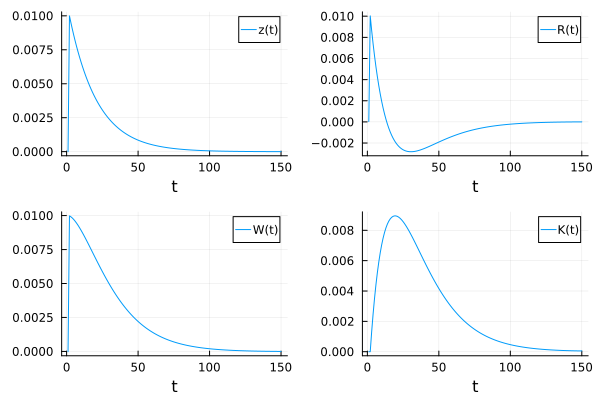

In [15]:
p1_TFP = plot(1:T, log.(ZT_TFP./ZT_TFP[end]).*100, label = "z(t)", xlabel= "t")
p2_TFP = plot(1:T, log.(r_path_TFP./r_path_TFP[end]).*100, label= "R(t)", xlabel= "t")
p3_TFP = plot(1:T, log.(w_path_TFP./w_path_TFP[end]).*100, label= "W(t)", xlabel= "t")
p4_TFP = plot(1:T, log.(K_path_TFP[end]./Kstar).*100, label= "K(t)", xlabel= "t" )

p5_TFP = plot(p1_TFP, p2_TFP, p3_TFP, p4_TFP)

## Business Cycle Simulation

We can also consider settings in which, at each point in time, the economy may experience a new realization of one or more aggregate shocks—such as total factor productivity ($Z_t$) and/or investment-specific technology ($Q_t$). Households respond to these shocks by making optimal decisions that take into account the entire history of past shocks.

For instance, in the case of only TFP shocks, the sequence of aggregate capital can be represented as a function of the entire history of shocks:

$$
K_t = \mathcal{K}(Z_t, Z_{t-1}, Z_{t-2}, \ldots)
$$

The Boppart-Krusell-Mitman (BKM) method relies on the assumption that the function $\mathcal{k}(\cdot)$ is linear with respect to the aggregate state(s). This allows the trajectory of capital following MIT shocks to be expressed as:

$$
K_t = Z_t \cdot \mathcal{K}(1, 0, 0, \ldots) + Z_{t-1} \cdot \mathcal{K}(0, 1, 0, \ldots) + Z_{t-2} \cdot \mathcal{K}(0, 0, 1, \ldots) + \ldots = \sum_{j=0}^{\infty} Z_{t-j} \cdot \mathcal{K}_j
$$

In other words, under the linearity assumption, the evolution of capital (and other aggregate variables) can be written as a moving average (MA) of past shocks.


**Scalability with Multiple Shocks**

A key advantage of linearity is scalability. If the economy is subject to multiple types of shocks, such as TFP and investment-specific technology, we only need to compute an impulse response function (IRF) for each shock individually. The overall effect is simply the sum of their contributions:

$$
K_t = \varepsilon^Z_t \cdot \gamma^Z_0 + \varepsilon^Q_t \cdot \gamma^Q_0 + \varepsilon^Z_{t-1} \cdot \gamma^Z_1 + \varepsilon^Q_{t-1} \cdot \gamma^Q_1 + \varepsilon^Z_{t-2} \cdot \gamma^Z_2 + \varepsilon^Q_{t-2} \cdot \gamma^Q_2 + \ldots
$$

Here:
- $\varepsilon^S_j$ denotes the realization of shock $S \in \{Z, Q\}$ at time $j$,
- $\gamma^S_k$ is the impulse response of capital at horizon $k$ to a shock to the aggregate state $S$.

Visual Representation

For example, the following impulse response functions (IRFs) for a TFP shock illustrate how capital respond over time following a one-time disturbance.

![Impulse responses of capital to TFP and MIT shocks](IRF.png)


This allows us to simulate business cycle dynamics by expressing aggregate variables as moving averages of past shocks. However, since we cannot store or compute an infinite sequence on a computer, we must choose a finite truncation point for the moving average (MA) representation.

Choosing a long lag length (e.g., MA(100)) ensures that we capture the full dynamic response of the variable, as it likely returns close to its steady state by the end of the horizon. However, this can be computationally intensive. On the other hand, selecting only a few lags (e.g., MA(0) or MA(1)) may lead to a poor approximation, as the variable may still be far from its steady state—thereby omitting important transitional dynamics.

Below are some illustrative examples of the capital response under different truncation choices:

MA(0): 
- $K_t = \gamma_0 \cdot \varepsilon_t$
- $K_{t+1} = \gamma_0 \cdot \varepsilon_{t+1}$
- $K_{t+h} = \gamma_0 \cdot \varepsilon_{t+h}$

MA(1): 
- $K_t = \gamma_0 \cdot \varepsilon_t + \gamma_1 \cdot \varepsilon_{t-1}$
- $K_{t+1} = \gamma_0 \cdot \varepsilon_{t+1} + \gamma_1 \cdot \varepsilon_{t}$
- $K_{t+h} = \gamma_0 \cdot \varepsilon_{t+h} + \gamma_1 \cdot \varepsilon_{t+h-1}$

MA(5): 
- $K_t = \gamma_0 \cdot \varepsilon_t + \gamma_1 \cdot \varepsilon_{t-1} + \gamma_2 \cdot \varepsilon_{t-2} + \gamma_3 \cdot \varepsilon_{t-3} + \gamma_4 \cdot \varepsilon_{t-4} + \gamma_5 \cdot \varepsilon_{t-5}$
- $K_{t+1} = \gamma_0 \cdot \varepsilon_{t+1} + \gamma_1 \cdot \varepsilon_{t} + \gamma_2 \cdot \varepsilon_{t-1} + \gamma_3 \cdot \varepsilon_{t-2} + \gamma_4 \cdot \varepsilon_{t-3} + \gamma_5 \cdot \varepsilon_{t-4}$
- $K_{t+h} = \gamma_0 \cdot \varepsilon_{t+h} + \gamma_1 \cdot \varepsilon_{t+h-1} + \gamma_2 \cdot \varepsilon_{t+h-2} + \gamma_3 \cdot \varepsilon_{t+h-3} + \gamma_4 \cdot \varepsilon_{t+h-4} + \gamma_5 \cdot \varepsilon_{t+h-5}$ 

This can be represented more generally as,

$$
MA(q) = 
\underbrace{
\begin{bmatrix}
    \gamma_0 & \gamma_1 & \cdots & \gamma_q
\end{bmatrix}
}_{1 \times q}
\underbrace{
\begin{bmatrix}
    \varepsilon_t \\
    \varepsilon_{t-1} \\
    \vdots \\
    \varepsilon_{t-q}
\end{bmatrix}
}_{q \times 1}
= \text{Scalar corresponding to period $t$} \rightarrow \text{Repeat this for $T$ periods}
$$

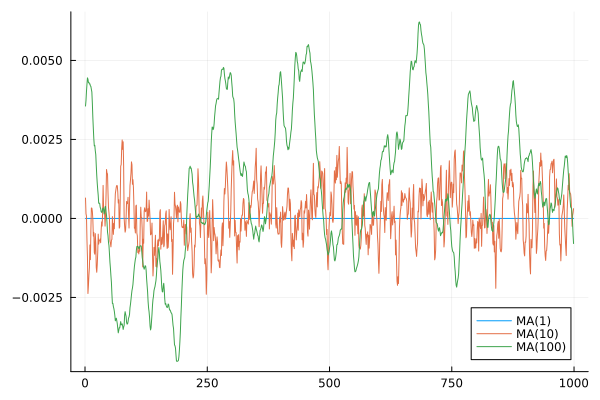

mean of MA(1) = 0.0
mean of MA(10) = 1.4276349240823917e-6
mean of MA(100) = 1.0214247594765034e-5
variance of MA(1) = 0.0
variance of MA(10) = 7.590777371126196e-11
variance of MA(100) = 5.350748964404687e-10


In [16]:
## Simulate Business Cycle with MIT shock solution

Kdev=log.(K_path[end]./Kstar)
Kdev_TFP=log.(K_path_TFP[end]./Kstar)
KFlip = reverse(Kdev,1)
KFlip_TFP = reverse(Kdev,1)

zshocks=randn(10000,1)*m_par.σ_Z
Qshocks=randn(10000,1)*m_par.σ_Q

Ksim1 = zeros(999,1)
approxlength=1 # truncation parameter, i.e. MA(1)
for t=2:1000
    Ksim1[t-1,1] = KFlip_TFP[T-approxlength+1:end]'*zshocks[t+1:t+approxlength] + KFlip[T-approxlength+1:end]'*Qshocks[t+1:t+approxlength]
end

Ksim10 = zeros(999,1)
approxlength=10 # truncation parameter, i.e. MA(10)
for t=2:1000
    Ksim10[t-1,1] = KFlip_TFP[T-approxlength+1:end]'*zshocks[t+1:t+approxlength] + KFlip[T-approxlength+1:end]'*Qshocks[t+1:t+approxlength]
end

Ksim100 = zeros(999,1)
approxlength=100 # truncation parameter, i.e. MA(100)
for t=2:1000
    Ksim100[t-1,1] = KFlip_TFP[T-approxlength+1:end]'*zshocks[t+1:t+approxlength] + KFlip[T-approxlength+1:end]'*Qshocks[t+1:t+approxlength]
end

sim = plot(100*Ksim1, label="MA(1)")
plot!(100*Ksim10, label="MA(10)")
plot!(100*Ksim100, label="MA(100)")
display(sim)

# Mean
μ_sim1 = mean(Ksim1)
println("mean of MA(1) = ",  μ_sim1)
μ_sim10 = mean(Ksim10)
println("mean of MA(10) = ",  μ_sim10)
μ_sim100 = mean(Ksim100)
println("mean of MA(100) = ",  μ_sim100)

# Variance
var_sim1 = var(Ksim1)
println("variance of MA(1) = ",  var_sim1)
var_sim10 = var(Ksim10)
println("variance of MA(10) = ",  var_sim10)
var_sim100 = var(Ksim100)
println("variance of MA(100) = ",  var_sim100)
